In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd
import torch
import torch.nn as nn
import torchdiffeq as ode
from cubic_spline import CSpline
from random_fields import GaussianRF
import math
import torch.nn.functional as F
import seaborn as sns
import time

def RBF(x1, x2, params):
    length_scale, output_scale = params 
    diffs = np.expand_dims(x1 / length_scale, 1) - \
            np.expand_dims(x2 / length_scale, 0)
    r2 = np.sum(diffs**2, axis=2)
    return output_scale * np.exp(-0.5 * r2)

def generate_gaussain_sample(gp_params,N,T):
    gp_samples = np.zeros((N,T))
    length_scale, output_scale = gp_params 
    jitter = 1e-10
    X = np.linspace(0.0, 1.0, T)[:,None]
    K = RBF(X, X, gp_params)
    L = np.linalg.cholesky(K + jitter*np.eye(T))
    for i in range(N):
        gp_sample = np.dot(L, np.random.normal(loc=0,scale=1,size=T))
        gp_samples[i,:] = gp_sample
    return gp_samples

class genc2(nn.Module):
    def __init__(self, k_x, k_y, f0):
        super(genc2, self).__init__()
        self.k_x = k_x
        self.k_y = k_y
        self.f0 = f0
        self.fit_data = None
        self.nu = 1e-3
        
        self.kx1 = (1j*k_x)**1
        self.kx2 = (1j*k_x)**2
        self.ky1 = (1j*k_y)**1
        self.ky2 = (1j*k_y)**2
        
        # Negative Laplace operator
        lap = k_x**2 + k_y**2
        lap[0,0] = 1.0
        
        self.lap = (1.0+0j)*lap
        self.dlap = (1.0+0j)/lap
        
    def forward(self, t, x):
        f0 = self.f0
        ut = self.fit_data.fit(t).expand(f0.shape)
        lap = self.lap; dlap = self.dlap
        kx1 = self.kx1; ky1 = self.ky1; nu = self.nu
        
        #f_h = f0*ut
        f_h = f0
        s_tilde = torch.fft.fft2(x)
        psi_h = s_tilde*dlap
        q = ky1*psi_h
        v = -kx1*psi_h
        w_x = kx1*s_tilde
        w_y = ky1*s_tilde
        F_h = torch.fft.ifft2(q).real * torch.fft.ifft2(w_x).real + \
            torch.fft.ifft2(v).real * torch.fft.ifft2(w_y).real 
        gu = -F_h + f_h - nu*torch.fft.ifft2(lap*s_tilde).real
        return(gu)
    
def gen_one2(sensor,f0):
    tt = torch.linspace(0, T, Nt+1)[:-1]
    xx = torch.linspace(0, L, Nx+1)[:-1]
    yy = torch.linspace(0, L, Ny+1)[:-1]
    
    GRF = GaussianRF(2, Nx, alpha=2.5, tau=7)
    y0 = GRF.sample(1).squeeze(0)
    
    k_max = math.floor(Nx/2.0)
    
    #Wavenumbers in y-direction
    k_y = 2*math.pi/L*torch.cat((torch.arange(start=0, end=k_max, step=1, device=f0.device),\
                    torch.arange(start=-k_max, end=0, step=1, device=f0.device)), 0).repeat(Ny,1)
    #Wavenumbers in x-direction
    k_x = k_y.transpose(0,1)
    
    gend = genc2(k_x,k_y,f0)
    
    funcu = CSpline(tt, sensor[0])
    gend.fit_data = funcu
    
    sol = ode.odeint(gend, y0, tt, rtol=1e-6, atol=1e-8, method='dopri5')
    return(xx, yy, tt, sol)

Ntr = 1
Nx = 64
Ny = Nx
Nt = 201
T = 50
L = 2
#L = 32*np.pi

length_scale = 0.1
output_scale = 1
gp_params = (length_scale, output_scale)

#Forcing function: 0.1*(sin(2pi(x+y)) + cos(2pi(x+y)))
t = torch.linspace(0, L, Nx+1)
t = t[0:-1]
X,Y = torch.meshgrid(t, t, indexing='ij')

ext_threshold = 100
u_train = np.zeros((Ntr,Nt))
s_train = np.zeros((Ntr,Nt,Nx,Ny))
f0_train = np.zeros((Ntr,Nx,Ny))

i = 0
while i<Ntr:
    print("train",i,Ntr)
    try:
        GRF = GaussianRF(2, Nx, alpha=2.5, tau=7)
        f0 = GRF.sample(1).squeeze(0)
        sensor = torch.tensor(generate_gaussain_sample(gp_params, 1, Nt))
        xx,yy,tt,s = gen_one2(sensor,f0)
        u_train[i] = sensor 
        s_train[i] = s.numpy()
        f0_train[i] = f0
    except:
        print("error")
    else:
        if np.isnan(s_train[i]).any():
            print("isnan")
        elif np.max(s_train[i])>ext_threshold:
            print("ext_threshold")
        else:
            i=i+1     
            

train 0 1


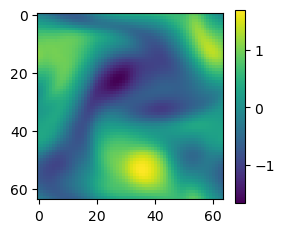

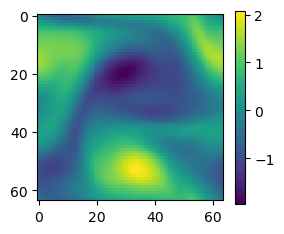

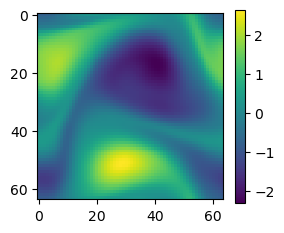

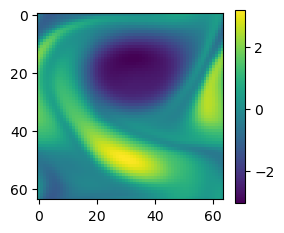

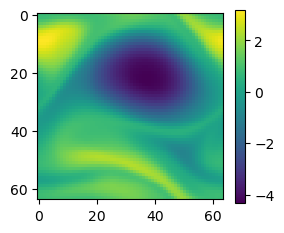

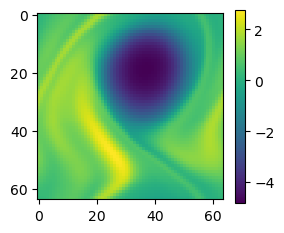

In [2]:
for t in [20,25,35,55,80,96]:
    fig = plt.figure(figsize=(3,2.5))
    u = s_train[0,t]
    #data = pd.DataFrame(u, index=np.round(np.linspace(0,2,Nx),3), columns=np.round(np.linspace(0,2,Ny),3))
    #cmap = sns.heatmap(data, cmap='inferno', center=u.mean())
    #plt.imshow(u, cmap='viridis', interpolation='nearest')

    #plt.imshow(u, interpolation='nearest', vmin=-1.2, vmax=1.2)
    plt.imshow(u, interpolation='nearest')
    plt.colorbar()
    #plt.savefig(str(t)+'.pdf')
    

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# 生成所有帧图片
os.makedirs("./frames", exist_ok=True)  # 创建保存帧的目录

for t in range(201):  # 遍历所有201个时间步
    fig = plt.figure(figsize=(3, 2.5))
    u = s_train[0, t]  # 提取当前时间步的数据
    plt.imshow(u, interpolation='nearest')
    plt.colorbar()
    
    # 使用三位数字补零命名，确保正确排序
    plt.savefig(f"./frames/write_{t:03d}.png", bbox_inches='tight')
    plt.close()  # 关闭图形释放内存

# 合成GIF动画
input_dir = "./frames"
output_gif = "./frames/animation.gif"
duration = 100  # 每帧显示时间（毫秒）
loop = 0        # 无限循环

# 获取排序后的图片列表
image_files = sorted(
    [os.path.join(input_dir, f) for f in os.listdir(input_dir) 
     if f.startswith("write_") and f.endswith(".png")],
    key=lambda x: int(x.split("_")[-1].split(".")[0])
)

# 转换成PIL图像对象并保存为GIF
images = [Image.open(f) for f in image_files]
images[0].save(
    output_gif,
    save_all=True,
    append_images=images[1:],
    duration=duration,
    loop=loop,
    optimize=True
)

print(f"GIF已成功生成：{output_gif}")



GIF已成功生成：./frames/animation.gif
